# Нелинейные ОДУ

In [16]:
import sys

sys.path.append('..')

### Пример

$y'(x) = y(x)(1 - y(x)), y(0) = 0.5$

##### Нахождение $y = y(x)$ методом Эйлера

In [17]:
import numpy as np
from modules.ode.linear.initial_value import euler

def f(x: float, y: np.ndarray[float]) -> np.ndarray[float]:
    fx = np.zeros(len(y))
    
    fx[0] = y[0]*(1 - y[0])

    return fx

a = 0.
b = 2.

ya = np.array([0.5])

N = [5, 25, 125]

re = [euler(f, a, b, ya, n) for n in N]

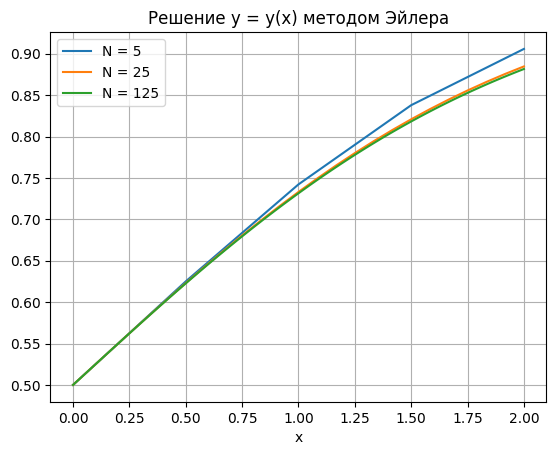

In [18]:
import matplotlib.pyplot as plt

for i in range(len(N)):
    plt.plot(re[i][0], re[i][1][:, 0], label=f'N = {N[i]}')

plt.title("Решение y = y(x) методом Эйлера")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Нахождение $y = y(x)$ модифицированным методом Эйлера

In [19]:
from modules.ode.linear.initial_value import modified_euler

rme = [modified_euler(f, a, b, ya, n) for n in N]

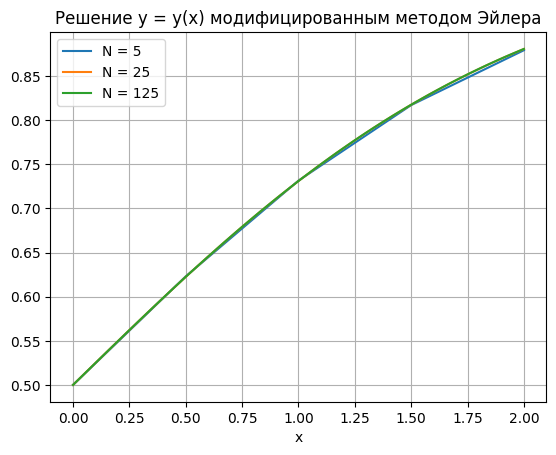

In [20]:
for i in range(len(N)):
    plt.plot(rme[i][0], rme[i][1][:, 0], label=f'N = {N[i]}')

plt.title("Решение y = y(x) модифицированным методом Эйлера")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Нахождение $y = y(x)$ методом Кранка-Николсона

$\frac{y(x+h) - y(x)}{h} = y(x + h/2) - y^2(x + h/2)$

$y(x + h/2) = \frac{1}{2}[y(x + h) + y(x)]$

$y^2(x + h/2) = y(x + h)y(x)$

$\frac{y(x+h) - y(x)}{h} = \frac{1}{2}[y(x + h) + y(x)] - y(x + h)y(x)$

$\frac{y_{i+1} - y_i}{h} = \frac{1}{2}[y_{i+1} + y_i] - y_{i+1}y_i$

$y_{i+1} = \frac{1 + h/2}{1 + hy_i - h/2}y_i$

In [21]:
x = [np.linspace(a, b, n) for n in N]
y = [np.zeros(n) for n in N]

for i in range(len(N)):
    h = x[i][1] - x[i][0]

    y[i][0] = 0.5

    for j in range(1, N[i]):
        y[i][j] = (1 + h/2)*y[i][j-1]/(1 + h*y[i][j-1] - h/2)

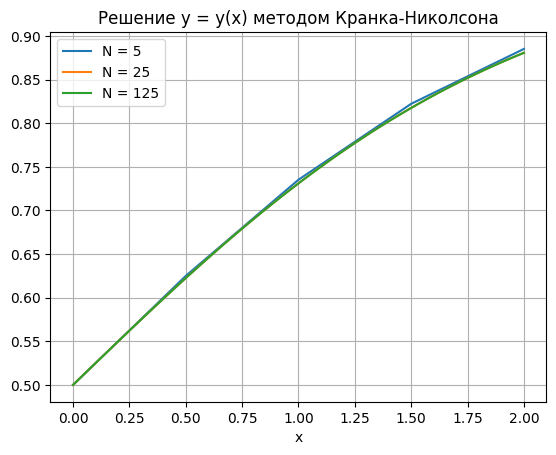

In [22]:
for i in range(len(N)):
    plt.plot(x[i], y[i], label=f'N = {N[i]}')

plt.title("Решение y = y(x) методом Кранка-Николсона")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Нахождение $y = y(x)$ одноитерационным методом Пикара

$\frac{y(x+h) - y(x)}{h} = y(x+h)[1 - y(x)]$

$\frac{y_{i+1} - y_i}{h} = y_{i+1}[1 - y_i]$

$y_{i+1} = \frac{y_i}{1 - h + y_ih}$

In [23]:
y = [np.zeros(n) for n in N]

for i in range(len(N)):
    h = x[i][1] - x[i][0]

    y[i][0] = 0.5

    for j in range(1, N[i]):
        y[i][j] = y[i][j-1]/(1 - h + y[i][j-1]*h)

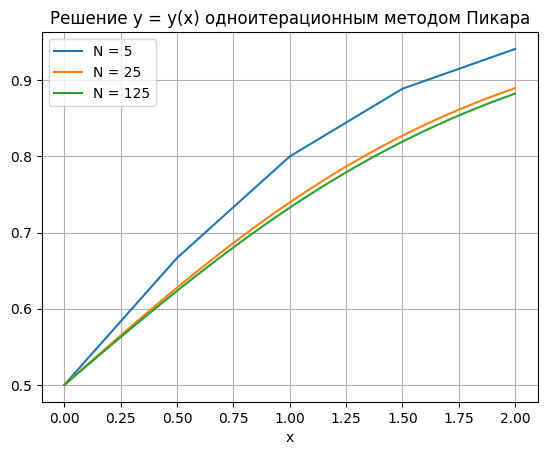

In [24]:
for i in range(len(N)):
    plt.plot(x[i], y[i], label=f'N = {N[i]}')

plt.title("Решение y = y(x) одноитерационным методом Пикара")
plt.xlabel('x')
plt.grid()
plt.legend()